## XGBoost

In [3]:
import sys
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    subprocess.run(["git", "clone", "https://github.com/DaTking4/ml-final-project-walmart-recruiting.git"], check=True)
    %cd ml-final-project-walmart-recruiting

    %pip install -q -r requirements.txt

    import os
    from google.colab import userdata
    os.environ["DAGSHUB_USER_TOKEN"] = userdata.get("DAGSHUB_TOKEN")
    os.environ["WANDB_API_KEY"]      = userdata.get("WANDB_API_KEY")
    os.environ["KAGGLE_API_TOKEN"]   = userdata.get("KAGGLE_API_TOKEN")

    %pip install -q kaggle
    import os
    os.makedirs("data", exist_ok=True)
    !kaggle competitions download -c walmart-recruiting-store-sales-forecasting -p data/ --quiet
    !unzip -q -o data/walmart-recruiting-store-sales-forecasting.zip -d data/

print("Running in:", "Google Colab" if IN_COLAB else "Local environment")


Running in: Local environment


### 1. Setup and Imports

In [1]:
import os
import sys
import importlib
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib"))

repo_root = Path.cwd()
while repo_root != repo_root.parent:
    if (repo_root / "src").exists():
        sys.path.insert(0, str(repo_root))
        break
    repo_root = repo_root.parent
else:
    raise FileNotFoundError("Could not locate repo root containing 'src'.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

import mlflow
import mlflow.pyfunc
from mlflow.models import infer_signature
import joblib

import wandb

def wandb_init_safe(**kwargs):
    try:
        return wandb.init(**kwargs)
    except Exception as exc:
        print(f"wandb.init failed ({exc!r}); retrying in offline mode -- "
              f"upload later with `wandb sync`")
        return wandb.init(mode="offline", **kwargs)

import src.mlflow_setup as mlflow_setup
importlib.reload(mlflow_setup)
init_tracking = mlflow_setup.init_tracking

from src.data_loading import load_merged
from src.transforms import apply_shared_features
from src.validation import time_based_split
from src.metrics import wmae_from_df
from src.xgb_utils import (
    add_lag_features, build_xgb_matrices, train_xgb,
    evaluate_xgb_config, XGB_FEATURE_COLS,
)
from src.pipeline.xgb_pipeline import XGBForecastPipeline

init_tracking()
assert "dagshub.com" in mlflow.get_tracking_uri(), mlflow.get_tracking_uri()

if mlflow.active_run() is not None:
    mlflow.end_run()

BLUE   = "#7196C7"
PINK   = "#AE737D"
PURPLE = "#705588"
RED    = "#7E3838"
GREEN  = "#5E9D74"

REGIME_COLORS = {"low_capacity": PURPLE, "mid_capacity": BLUE,
                 "high_capacity": RED, "refined": PINK}
STATUS_COLORS = {"good": GREEN, "underfit": PURPLE, "overfit": RED}

print("Setup complete.")


Accessing as lchit22

Initialized MLflow to track repo "dkhak22/ml-final-project-store-sales-forecasting"

Repository dkhak22/ml-final-project-store-sales-forecasting initialized!

MLflow tracking URI: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow
Setup complete.


### 2. Configuration

In [2]:
init_tracking()
assert "dagshub.com" in mlflow.get_tracking_uri(), mlflow.get_tracking_uri()

EXPERIMENT_NAME = "XGBoost_Training"
mlflow.set_experiment(EXPERIMENT_NAME)

WANDB_ENTITY  = "dkhak22-free-university-of-tbilisi-"
WANDB_PROJECT = "walmart-sales-forecasting"

CONFIG = {
    "horizon":      26,
    "random_seed":  42,
}

MODEL_COL = "XGBoost"
FREQ      = "W-FRI"

CONFIG


Initialized MLflow to track repo "dkhak22/ml-final-project-store-sales-forecasting"

Repository dkhak22/ml-final-project-store-sales-forecasting initialized!

MLflow tracking URI: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow


{'horizon': 26, 'random_seed': 42}

### 3. Load Data

In [3]:
train_df, test_df = load_merged()

print(f"train_df: {train_df.shape}")
print(f"test_df:  {test_df.shape}")

CONFIG["horizon"] = test_df["Date"].nunique()

train_df.head()


train_df: (421570, 16)
test_df:  (115064, 15)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


### 4. Shared Preprocessing and Feature Engineering

In [4]:
train_feat = apply_shared_features(train_df)
test_feat  = apply_shared_features(test_df)

print(f"Columns after shared feature engineering: {train_feat.columns.tolist()}")
train_feat.head()


Columns after shared feature engineering: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Size', 'Type_A', 'Type_B', 'Type_C', 'Year', 'Month', 'WeekOfYear', 'DaysSinceLastHoliday', 'DaysToNextHoliday']


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Unemployment,Size,Type_A,Type_B,Type_C,Year,Month,WeekOfYear,DaysSinceLastHoliday,DaysToNextHoliday
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,5,inf,7.0
1,1,1,2010-02-12,46039.49,1,38.51,2.548,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,6,0.0,0.0
2,1,1,2010-02-19,41595.55,0,39.93,2.514,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,7,7.0,203.0
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,8,14.0,196.0
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,3,9,21.0,189.0


### 5. Feature Decision

In [5]:
XGB_FEATURE_DECISION = {
    "feature_set": "full_exogenous",
    "uses_exogenous_features": True,
    "used_features": XGB_FEATURE_COLS,
    "reason": (
        "XGBoost is a tabular model that supports all available features. "
        "Lag features (lag_26, lag_52) capture autoregressive structure without "
        "future leakage. Rolling stats are shifted by 26 weeks before computing "
        "so they are available at the 26-week test horizon. Holiday weighting "
        "(w=5) is passed via sample_weight during training."
    ),
}

print("Feature set:", XGB_FEATURE_DECISION["feature_set"])
print("Number of features:", len(XGB_FEATURE_COLS))
print("Features:", XGB_FEATURE_COLS)


Feature set: full_exogenous
Number of features: 29
Features: ['lag_26', 'lag_52', 'rolling_mean_4', 'rolling_mean_13', 'rolling_mean_26', 'rolling_std_4', 'rolling_std_13', 'rolling_std_26', 'WeekOfYear', 'Month', 'Year', 'Type_A', 'Type_B', 'Type_C', 'Size', 'IsHoliday', 'DaysSinceLastHoliday', 'DaysToNextHoliday', 'Fuel_Price', 'Temperature', 'CPI', 'Unemployment', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'Store', 'Dept']


### 6. XGBoost Lag Feature Engineering

In [6]:
train_feat = add_lag_features(train_feat)

lag_cols = [c for c in train_feat.columns if c.startswith("lag_") or c.startswith("rolling_")]
print("Lag / rolling columns added:", lag_cols)
print(f"Rows with any NaN in lag cols: {train_feat[lag_cols].isna().any(axis=1).sum():,}")
train_feat.head()


Lag / rolling columns added: ['lag_26', 'lag_52', 'rolling_mean_4', 'rolling_std_4', 'rolling_mean_13', 'rolling_std_13', 'rolling_mean_26', 'rolling_std_26']
Rows with any NaN in lag cols: 160,487


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,DaysSinceLastHoliday,DaysToNextHoliday,lag_26,lag_52,rolling_mean_4,rolling_std_4,rolling_mean_13,rolling_std_13,rolling_mean_26,rolling_std_26
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.0,0.0,0.0,...,inf,7.0,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0
1,1,1,2010-02-12,46039.49,1,38.51,2.548,0.0,0.0,0.0,...,0.0,0.0,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0
2,1,1,2010-02-19,41595.55,0,39.93,2.514,0.0,0.0,0.0,...,7.0,203.0,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.0,0.0,0.0,...,14.0,196.0,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.0,0.0,0.0,...,21.0,189.0,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0


### 7. Train / Validation Split and Matrix Build

In [7]:
train_part, valid_part = time_based_split(
    train_feat,
    valid_weeks=CONFIG["horizon"],
)

print(f"Train part: {train_part['Date'].min().date()} -> {train_part['Date'].max().date()}")
print(f"Valid part: {valid_part['Date'].min().date()} -> {valid_part['Date'].max().date()}")

X_train, y_train, w_train, train_clean = build_xgb_matrices(train_part, XGB_FEATURE_COLS)
X_val,   y_val,   w_val,   val_clean   = build_xgb_matrices(valid_part, XGB_FEATURE_COLS)

print(f"\nX_train: {X_train.shape}  (after dropping NaN lag rows)")
print(f"X_val:   {X_val.shape}")
print(f"Holiday rows in train: {(w_train == 5.0).sum():,}")
print(f"Holiday rows in val:   {(w_val == 5.0).sum():,}")


def fit_gap_pct(train_wmae, val_wmae):
    if pd.isna(train_wmae) or train_wmae == 0:
        return float("nan")
    return ((val_wmae - train_wmae) / train_wmae) * 100


def classify_fit_status(train_wmae, val_wmae):
    gap = fit_gap_pct(train_wmae, val_wmae)
    if pd.isna(gap):
        return "unknown"
    if gap > 25:
        return "overfit"
    if gap < -10:
        return "underfit"
    return "good"


Train part: 2010-02-05 -> 2012-01-27
Valid part: 2012-02-03 -> 2012-10-26

X_train: (147894, 29)  (after dropping NaN lag rows)
X_val:   (113189, 29)
Holiday rows in train: 11,396
Holiday rows in val:   5,807


### 8. Sanity Check

In [8]:
sanity_config = {
    "n_estimators": 10,
    "max_depth": 3,
    "learning_rate": 0.3,
}

sanity_model, sanity_train_wmae, sanity_val_wmae = evaluate_xgb_config(
    config=sanity_config,
    X_train=X_train.head(500),
    y_train=y_train.head(500),
    w_train=w_train[:500],
    X_val=X_val.head(200),
    val_meta=val_clean.head(200),
    model_col=MODEL_COL,
)

print(f"Sanity train WMAE: {sanity_train_wmae:,.2f}")
print(f"Sanity val   WMAE: {sanity_val_wmae:,.2f}")
print("Sanity check passed.")


Sanity train WMAE: 1,994.53
Sanity val   WMAE: 2,866.80
Sanity check passed.


### 9. Baseline Run

In [ ]:
baseline_config = {
    "label":         "baseline_xgb",
    "regime":        "baseline",
    "n_estimators":  300,
    "max_depth":     5,
    "learning_rate": 0.05,
    "subsample":     0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "reg_lambda":    1.0,
    "reg_alpha":     0.0,
}

with mlflow.start_run(run_name="XGBoost_Baseline") as run:
    try:
        wandb_init_safe(
            entity=WANDB_ENTITY,
            project=WANDB_PROJECT,
            name="XGBoost_Baseline",
            group="XGBoost",
            job_type="baseline",
            tags=["XGBoost", "baseline", "full_exogenous"],
            config={**CONFIG, **baseline_config, **XGB_FEATURE_DECISION},
            reinit="finish_previous",
        )
        baseline_model, baseline_train_wmae, baseline_val_wmae = evaluate_xgb_config(
            config=baseline_config,
            X_train=X_train,
            y_train=y_train,
            w_train=w_train,
            X_val=X_val,
            val_meta=val_clean,
            model_col=MODEL_COL,
        )

        gap = fit_gap_pct(baseline_train_wmae, baseline_val_wmae)
        status = classify_fit_status(baseline_train_wmae, baseline_val_wmae)

        mlflow.log_params({k: v for k, v in baseline_config.items() if k not in ("label", "regime")})
        mlflow.log_params({
            "model":         "XGBoost",
            "feature_set":   XGB_FEATURE_DECISION["feature_set"],
            "n_features":    len(XGB_FEATURE_COLS),
            "gradient_logging_applicable": False,
        })
        mlflow.log_metrics({
            "train_wmae": baseline_train_wmae,
            "val_wmae":   baseline_val_wmae,
            "gap_pct":    gap,
        })

        wandb.log({
            "train_wmae": baseline_train_wmae,
            "val_wmae":   baseline_val_wmae,
            "gap_pct":    gap,
            "status":     status,
        })

        print(f"Baseline train WMAE: {baseline_train_wmae:,.2f}")
        print(f"Baseline val   WMAE: {baseline_val_wmae:,.2f}")
        print(f"Gap: {gap:.1f}%  Status: {status}")

    finally:
        wandb.finish()


### 10. Hyperparameter Grid

One combined grid: capacity-regime configs (low / mid / high) for the bias-variance analysis, plus refined configs targeting the region that performed best.

In [10]:


param_grid = [
    # -- low capacity: few shallow trees, heavy regularization ----------------
    {"n_estimators": 50,  "max_depth": 2, "learning_rate": 0.3,  "subsample": 1.0, "colsample_bytree": 1.0, "min_child_weight": 20, "reg_lambda": 10.0, "reg_alpha": 0.0, "label": "low_capacity_1", "regime": "low_capacity"},
    {"n_estimators": 50,  "max_depth": 2, "learning_rate": 0.3,  "subsample": 1.0, "colsample_bytree": 1.0, "min_child_weight": 50, "reg_lambda": 10.0, "reg_alpha": 5.0, "label": "low_capacity_2", "regime": "low_capacity"},
    {"n_estimators": 30,  "max_depth": 2, "learning_rate": 0.5,  "subsample": 1.0, "colsample_bytree": 1.0, "min_child_weight": 50, "reg_lambda": 20.0, "reg_alpha": 0.0, "label": "low_capacity_3", "regime": "low_capacity"},
    {"n_estimators": 100, "max_depth": 2, "learning_rate": 0.3,  "subsample": 1.0, "colsample_bytree": 0.5, "min_child_weight": 30, "reg_lambda": 10.0, "reg_alpha": 0.0, "label": "low_capacity_4", "regime": "low_capacity"},
    {"n_estimators": 50,  "max_depth": 3, "learning_rate": 0.3,  "subsample": 0.5, "colsample_bytree": 0.5, "min_child_weight": 50, "reg_lambda": 5.0,  "reg_alpha": 0.0, "label": "low_capacity_5", "regime": "low_capacity"},
    {"n_estimators": 30,  "max_depth": 2, "learning_rate": 0.5,  "subsample": 0.5, "colsample_bytree": 1.0, "min_child_weight": 100,"reg_lambda": 20.0, "reg_alpha": 10.0,"label": "low_capacity_6", "regime": "low_capacity"},

    # -- mid capacity: moderate depth/trees, standard regularization ----------
    {"n_estimators": 200, "max_depth": 4, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 5,  "reg_lambda": 1.0,  "reg_alpha": 0.0, "label": "mid_capacity_1",  "regime": "mid_capacity"},
    {"n_estimators": 300, "max_depth": 4, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 5,  "reg_lambda": 1.0,  "reg_alpha": 0.0, "label": "mid_capacity_2",  "regime": "mid_capacity"},
    {"n_estimators": 300, "max_depth": 5, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 5,  "reg_lambda": 1.0,  "reg_alpha": 0.0, "label": "mid_capacity_3",  "regime": "mid_capacity"},
    {"n_estimators": 300, "max_depth": 5, "learning_rate": 0.05, "subsample": 0.7, "colsample_bytree": 0.7, "min_child_weight": 10, "reg_lambda": 2.0,  "reg_alpha": 0.1, "label": "mid_capacity_4",  "regime": "mid_capacity"},
    {"n_estimators": 500, "max_depth": 4, "learning_rate": 0.03, "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 5,  "reg_lambda": 1.0,  "reg_alpha": 0.0, "label": "mid_capacity_5",  "regime": "mid_capacity"},
    {"n_estimators": 500, "max_depth": 5, "learning_rate": 0.03, "subsample": 0.8, "colsample_bytree": 0.7, "min_child_weight": 5,  "reg_lambda": 1.0,  "reg_alpha": 0.0, "label": "mid_capacity_6",  "regime": "mid_capacity"},
    {"n_estimators": 300, "max_depth": 6, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 3,  "reg_lambda": 1.0,  "reg_alpha": 0.0, "label": "mid_capacity_7",  "regime": "mid_capacity"},
    {"n_estimators": 300, "max_depth": 6, "learning_rate": 0.05, "subsample": 0.7, "colsample_bytree": 0.7, "min_child_weight": 10, "reg_lambda": 3.0,  "reg_alpha": 0.5, "label": "mid_capacity_8",  "regime": "mid_capacity"},
    {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.1,  "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 5,  "reg_lambda": 1.0,  "reg_alpha": 0.0, "label": "mid_capacity_9",  "regime": "mid_capacity"},
    {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.1,  "subsample": 0.7, "colsample_bytree": 0.8, "min_child_weight": 10, "reg_lambda": 2.0,  "reg_alpha": 0.0, "label": "mid_capacity_10", "regime": "mid_capacity"},
    {"n_estimators": 400, "max_depth": 4, "learning_rate": 0.05, "subsample": 0.9, "colsample_bytree": 0.9, "min_child_weight": 5,  "reg_lambda": 1.5,  "reg_alpha": 0.0, "label": "mid_capacity_11", "regime": "mid_capacity"},
    {"n_estimators": 400, "max_depth": 5, "learning_rate": 0.05, "subsample": 0.9, "colsample_bytree": 0.9, "min_child_weight": 5,  "reg_lambda": 1.5,  "reg_alpha": 0.0, "label": "mid_capacity_12", "regime": "mid_capacity"},
    {"n_estimators": 300, "max_depth": 5, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 5,  "reg_lambda": 1.0,  "reg_alpha": 1.0, "label": "mid_capacity_13", "regime": "mid_capacity"},
    {"n_estimators": 300, "max_depth": 6, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.6, "min_child_weight": 5,  "reg_lambda": 2.0,  "reg_alpha": 0.5, "label": "mid_capacity_14", "regime": "mid_capacity"},
    {"n_estimators": 500, "max_depth": 5, "learning_rate": 0.03, "subsample": 0.7, "colsample_bytree": 0.7, "min_child_weight": 10, "reg_lambda": 2.0,  "reg_alpha": 0.5, "label": "mid_capacity_15", "regime": "mid_capacity"},
    {"n_estimators": 200, "max_depth": 6, "learning_rate": 0.1,  "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 3,  "reg_lambda": 1.0,  "reg_alpha": 0.0, "label": "mid_capacity_16", "regime": "mid_capacity"},
    {"n_estimators": 400, "max_depth": 6, "learning_rate": 0.03, "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 5,  "reg_lambda": 1.0,  "reg_alpha": 0.0, "label": "mid_capacity_17", "regime": "mid_capacity"},
    {"n_estimators": 500, "max_depth": 6, "learning_rate": 0.03, "subsample": 0.7, "colsample_bytree": 0.7, "min_child_weight": 10, "reg_lambda": 3.0,  "reg_alpha": 1.0, "label": "mid_capacity_18", "regime": "mid_capacity"},

    # -- high capacity: many deep trees, little/no regularization -------------
    {"n_estimators": 2000, "max_depth": 8,  "learning_rate": 0.01, "subsample": 1.0, "colsample_bytree": 1.0, "min_child_weight": 1, "reg_lambda": 0.0, "reg_alpha": 0.0, "label": "high_capacity_1", "regime": "high_capacity"},
    {"n_estimators": 1000, "max_depth": 10, "learning_rate": 0.01, "subsample": 1.0, "colsample_bytree": 1.0, "min_child_weight": 1, "reg_lambda": 0.0, "reg_alpha": 0.0, "label": "high_capacity_2", "regime": "high_capacity"},
    {"n_estimators": 2000, "max_depth": 10, "learning_rate": 0.01, "subsample": 1.0, "colsample_bytree": 1.0, "min_child_weight": 1, "reg_lambda": 0.0, "reg_alpha": 0.0, "label": "high_capacity_3", "regime": "high_capacity"},
    {"n_estimators": 1000, "max_depth": 8,  "learning_rate": 0.005,"subsample": 1.0, "colsample_bytree": 1.0, "min_child_weight": 1, "reg_lambda": 0.0, "reg_alpha": 0.0, "label": "high_capacity_4", "regime": "high_capacity"},
    {"n_estimators": 2000, "max_depth": 8,  "learning_rate": 0.005,"subsample": 0.9, "colsample_bytree": 0.9, "min_child_weight": 1, "reg_lambda": 0.1, "reg_alpha": 0.0, "label": "high_capacity_5", "regime": "high_capacity"},
    {"n_estimators": 3000, "max_depth": 6,  "learning_rate": 0.005,"subsample": 1.0, "colsample_bytree": 1.0, "min_child_weight": 1, "reg_lambda": 0.0, "reg_alpha": 0.0, "label": "high_capacity_6", "regime": "high_capacity"},

    # -- refined: targeted search around the winning high-capacity region -----
    {"n_estimators": 2500, "max_depth": 8, "learning_rate": 0.004, "subsample": 0.90, "colsample_bytree": 0.90, "min_child_weight": 1, "reg_lambda": 0.1, "reg_alpha": 0.0, "gamma": 0.0, "label": "refine_1",  "regime": "refined"},
    {"n_estimators": 3000, "max_depth": 8, "learning_rate": 0.003, "subsample": 0.85, "colsample_bytree": 0.85, "min_child_weight": 1, "reg_lambda": 0.1, "reg_alpha": 0.0, "gamma": 0.0, "label": "refine_2",  "regime": "refined"},
    {"n_estimators": 2000, "max_depth": 7, "learning_rate": 0.005, "subsample": 0.90, "colsample_bytree": 0.90, "min_child_weight": 1, "reg_lambda": 0.05,"reg_alpha": 0.0, "gamma": 0.0, "label": "refine_3",  "regime": "refined"},
    {"n_estimators": 2000, "max_depth": 9, "learning_rate": 0.005, "subsample": 0.90, "colsample_bytree": 0.90, "min_child_weight": 1, "reg_lambda": 0.2, "reg_alpha": 0.0, "gamma": 0.0, "label": "refine_4",  "regime": "refined"},
    {"n_estimators": 2500, "max_depth": 8, "learning_rate": 0.005, "subsample": 0.95, "colsample_bytree": 0.95, "min_child_weight": 0, "reg_lambda": 0.1, "reg_alpha": 0.0, "gamma": 0.0, "label": "refine_5",  "regime": "refined"},
    {"n_estimators": 2000, "max_depth": 8, "learning_rate": 0.005, "subsample": 0.90, "colsample_bytree": 0.90, "min_child_weight": 2, "reg_lambda": 0.1, "reg_alpha": 0.0, "gamma": 0.1, "label": "refine_6",  "regime": "refined"},
    {"n_estimators": 2500, "max_depth": 8, "learning_rate": 0.005, "subsample": 0.90, "colsample_bytree": 0.80, "colsample_bylevel": 0.8, "min_child_weight": 1, "reg_lambda": 0.1, "reg_alpha": 0.0, "gamma": 0.0, "label": "refine_7",  "regime": "refined"},
    {"n_estimators": 3500, "max_depth": 7, "learning_rate": 0.003, "subsample": 0.90, "colsample_bytree": 0.90, "min_child_weight": 1, "reg_lambda": 0.1, "reg_alpha": 0.0, "gamma": 0.0, "label": "refine_8",  "regime": "refined"},
    {"n_estimators": 2000, "max_depth": 8, "learning_rate": 0.005, "subsample": 0.90, "colsample_bytree": 0.90, "min_child_weight": 1, "reg_lambda": 0.3, "reg_alpha": 0.3, "gamma": 0.0, "label": "refine_9",  "regime": "refined"},
    {"n_estimators": 4000, "max_depth": 6, "learning_rate": 0.003, "subsample": 0.90, "colsample_bytree": 0.90, "min_child_weight": 1, "reg_lambda": 0.1, "reg_alpha": 0.0, "gamma": 0.0, "label": "refine_10", "regime": "refined"},
]

print(f"Total configs: {len(param_grid)}")
regime_counts = {r: sum(1 for c in param_grid if c["regime"] == r)
                 for r in ["low_capacity", "mid_capacity", "high_capacity", "refined"]}
print("By regime:", regime_counts)


Total configs: 40
By regime: {'low_capacity': 6, 'mid_capacity': 18, 'high_capacity': 6, 'refined': 10}


### 11. XGBoost Experiments

In [ ]:
results      = []
best_val_wmae = float("inf")
best_run_id   = None
best_label    = None
best_model    = None

with mlflow.start_run(run_name="XGBoost_HyperparamSweep") as parent_run:
    mlflow.log_param("n_configs",    len(param_grid))
    mlflow.log_param("model",        "XGBoost")
    mlflow.log_param("feature_set",  XGB_FEATURE_DECISION["feature_set"])
    mlflow.log_param("n_features",   len(XGB_FEATURE_COLS))
    mlflow.log_param("gradient_logging_applicable", False)

    for idx, original_config in enumerate(param_grid, start=1):
        config = original_config.copy()
        label  = config.pop("label")
        regime = config.pop("regime")

        with mlflow.start_run(run_name=f"XGBoost_{label}", nested=True) as nested_run:
            try:
                wandb_init_safe(
                    entity=WANDB_ENTITY,
                    project=WANDB_PROJECT,
                    name=f"XGBoost_{label}",
                    group="XGBoost",
                    job_type="hyperparam_sweep",
                    tags=["XGBoost", regime],
                    config={**CONFIG, **config, "label": label, "regime": regime},
                    reinit="finish_previous",
                )
                model, train_wmae, val_wmae = evaluate_xgb_config(
                    config=config,
                    X_train=X_train,
                    y_train=y_train,
                    w_train=w_train,
                    X_val=X_val,
                    val_meta=val_clean,
                    model_col=MODEL_COL,
                )

                gap    = fit_gap_pct(train_wmae, val_wmae)
                status = classify_fit_status(train_wmae, val_wmae)

                mlflow.log_params({**config, "label": label, "regime": regime,
                                   "feature_set": XGB_FEATURE_DECISION["feature_set"]})
                mlflow.log_metrics({"train_wmae": train_wmae, "val_wmae": val_wmae, "gap_pct": gap})

                wandb.log({"train_wmae": train_wmae, "val_wmae": val_wmae,
                           "gap_pct": gap, "status": status})

                results.append({
                    "label": label, "regime": regime, "status": status,
                    "feature_set": XGB_FEATURE_DECISION["feature_set"],
                    **config,
                    "train_wmae": train_wmae, "val_wmae": val_wmae, "gap_pct": gap,
                    "run_id": nested_run.info.run_id,
                })

                if val_wmae < best_val_wmae:
                    best_val_wmae = val_wmae
                    best_run_id   = nested_run.info.run_id
                    best_label    = label
                    best_model    = model

                print(f"[{idx:02d}/{len(param_grid)}] {label:<16} train={train_wmae:,.0f}  val={val_wmae:,.0f}  gap={gap:+.1f}%  {status}")

            except Exception as exc:
                print(f"[{idx:02d}/{len(param_grid)}] {label} FAILED: {exc}")
                mlflow.log_param("error", str(exc))

            finally:
                wandb.finish()

print(f"\nBest: {best_label}  val_wmae={best_val_wmae:,.2f}")


### 13. Results

In [12]:
results_df = pd.DataFrame(results).sort_values("val_wmae").reset_index(drop=True)

display_cols = [
    "label", "regime", "status",
    "n_estimators", "max_depth", "learning_rate",
    "subsample", "colsample_bytree", "min_child_weight",
    "reg_lambda", "reg_alpha",
    "train_wmae", "val_wmae", "gap_pct",
]

display(results_df[display_cols].head(15))

os.makedirs("reports", exist_ok=True)
results_path = "reports/xgboost_results.csv"
results_df.to_csv(results_path, index=False)

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(results_path)
    mlflow.log_metric("best_val_wmae", best_val_wmae)

print(f"\nBest: {best_label}  val_wmae={best_val_wmae:,.2f}")


,label,regime,status,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,reg_lambda,reg_alpha,train_wmae,val_wmae,gap_pct
0,refine_4,refined,overfit,2000,9,0.005,0.90,0.90,1,0.20,0.0,1056.920524,1692.150490,60.101961
1,refine_7,refined,overfit,2500,8,0.005,0.90,0.80,1,0.10,0.0,1144.403944,1699.146811,48.474393
2,refine_6,refined,overfit,2000,8,0.005,0.90,0.90,2,0.10,0.0,1211.471612,1707.707954,40.961450
3,refine_1,refined,overfit,2500,8,0.004,0.90,0.90,1,0.10,0.0,1211.901544,1708.856584,41.006222
4,refine_9,refined,overfit,2000,8,0.005,0.90,0.90,1,0.30,0.3,1214.392740,1708.913504,40.721650
5,high_capacity_5,high_capacity,overfit,2000,8,0.005,0.90,0.90,1,0.10,0.0,1212.483292,1709.593236,40.999323
6,refine_2,refined,overfit,3000,8,0.003,0.85,0.85,1,0.10,0.0,1244.709227,1711.388118,37.493005
7,refine_5,refined,overfit,2500,8,0.005,0.95,0.95,0,0.10,0.0,1152.993106,1712.232514,48.503274
8,high_capacity_4,high_capacity,good,1000,8,0.005,1.00,1.00,1,0.00,0.0,1407.219442,1723.548708,22.479029
9,high_capacity_2,high_capacity,overfit,1000,10,0.010,1.00,1.00,1,0.00,0.0,893.186702,1723.901231,93.005698


2026/07/16 14:16:36 INFO mlflow.tracking._tracking_service.client: 🏃 View run XGBoost_refine_4 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7/runs/87c73c7000ca4663b6c2da9b4532ee2b.
2026/07/16 14:16:36 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7.



Best: refine_4  val_wmae=1,692.15


### 14. Plots

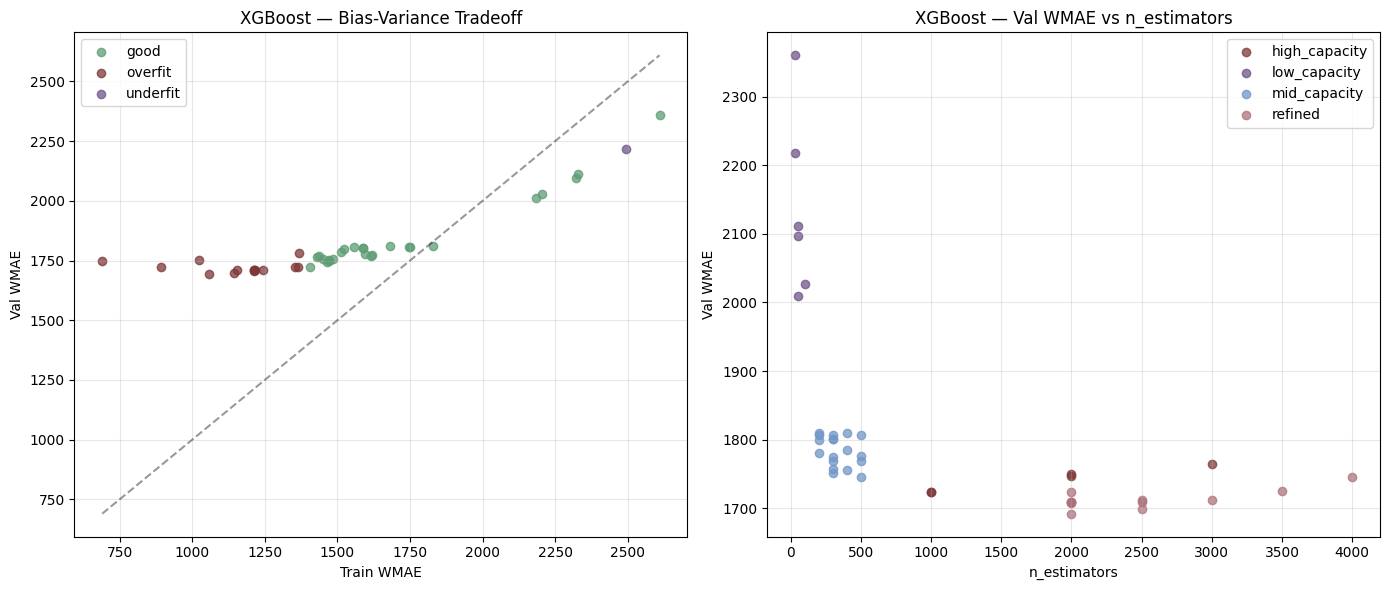

2026/07/16 14:16:45 INFO mlflow.tracking._tracking_service.client: 🏃 View run XGBoost_refine_4 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7/runs/87c73c7000ca4663b6c2da9b4532ee2b.
2026/07/16 14:16:45 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7.


In [13]:
os.makedirs("Plots", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for status, sdf in results_df.groupby("status"):
    axes[0].scatter(sdf["train_wmae"], sdf["val_wmae"],
                    c=STATUS_COLORS.get(status, BLUE), alpha=0.75, label=status)

lo = float(results_df[["train_wmae", "val_wmae"]].min().min())
hi = float(results_df[["train_wmae", "val_wmae"]].max().max())
axes[0].plot([lo, hi], [lo, hi], "k--", alpha=0.4)
axes[0].set_xlabel("Train WMAE"); axes[0].set_ylabel("Val WMAE")
axes[0].set_title("XGBoost — Bias-Variance Tradeoff")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

for regime, rdf in results_df.groupby("regime"):
    axes[1].scatter(rdf["n_estimators"], rdf["val_wmae"],
                    c=REGIME_COLORS.get(regime, BLUE), alpha=0.75, label=regime)

axes[1].set_xlabel("n_estimators"); axes[1].set_ylabel("Val WMAE")
axes[1].set_title("XGBoost — Val WMAE vs n_estimators")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plot_path = "Plots/xgboost_sweep.png"
plt.savefig(plot_path, dpi=200)
plt.show()

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(plot_path)


### 15. Error Analysis

In [15]:
val_clean_copy = val_clean.copy()
val_clean_copy[MODEL_COL] = best_model.predict(X_val)
val_clean_copy["abs_error"] = (val_clean_copy["Weekly_Sales"] - val_clean_copy[MODEL_COL]).abs()

worst_store_dept = (
    val_clean_copy.groupby(["Store", "Dept"])["abs_error"]
    .mean().sort_values(ascending=False).head(15)
)
display(worst_store_dept)

holiday_error = val_clean_copy.groupby("IsHoliday")["abs_error"].mean()
display(holiday_error)

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_metric("holiday_week_mae",     float(val_clean_copy[val_clean_copy["IsHoliday"] == 1]["abs_error"].mean()))
    mlflow.log_metric("non_holiday_week_mae", float(val_clean_copy[val_clean_copy["IsHoliday"] == 0]["abs_error"].mean()))


Store  Dept
14     92      27217.619487
       95      21086.408902
18     92      19256.011490
10     72      16412.860264
14     90      15133.167436
38     38      14616.116094
14     72      12808.540465
10     18      12573.185420
14     38      12203.132724
20     72      12066.438458
13     1       11671.834467
20     38      11341.528670
31     92      10970.222524
20     95      10916.881795
31     90      10804.480481
Name: abs_error, dtype: float64

IsHoliday
0    1685.440272
1    1716.967316
Name: abs_error, dtype: float64

2026/07/16 14:17:07 INFO mlflow.tracking._tracking_service.client: 🏃 View run XGBoost_refine_4 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7/runs/87c73c7000ca4663b6c2da9b4532ee2b.
2026/07/16 14:17:07 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7.


### 16. Error Plots

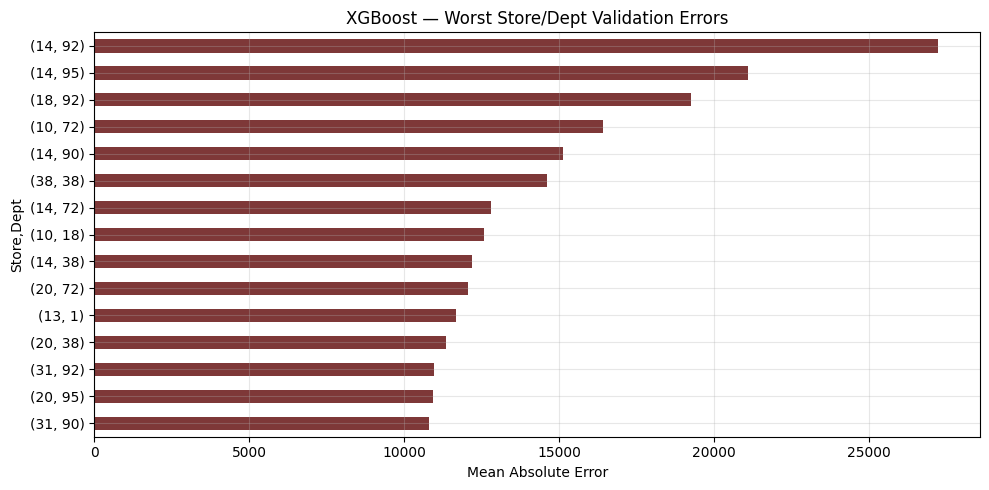

2026/07/16 14:17:12 INFO mlflow.tracking._tracking_service.client: 🏃 View run XGBoost_refine_4 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7/runs/87c73c7000ca4663b6c2da9b4532ee2b.
2026/07/16 14:17:12 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7.


In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
worst_store_dept.sort_values().plot(kind="barh", ax=ax, color=RED)
ax.set_xlabel("Mean Absolute Error")
ax.set_title("XGBoost — Worst Store/Dept Validation Errors")
ax.grid(True, alpha=0.3)
plt.tight_layout()
error_plot_path = "Plots/xgboost_worst_store_dept.png"
plt.savefig(error_plot_path, dpi=200)
plt.show()

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(error_plot_path)


### 17. Feature Importance

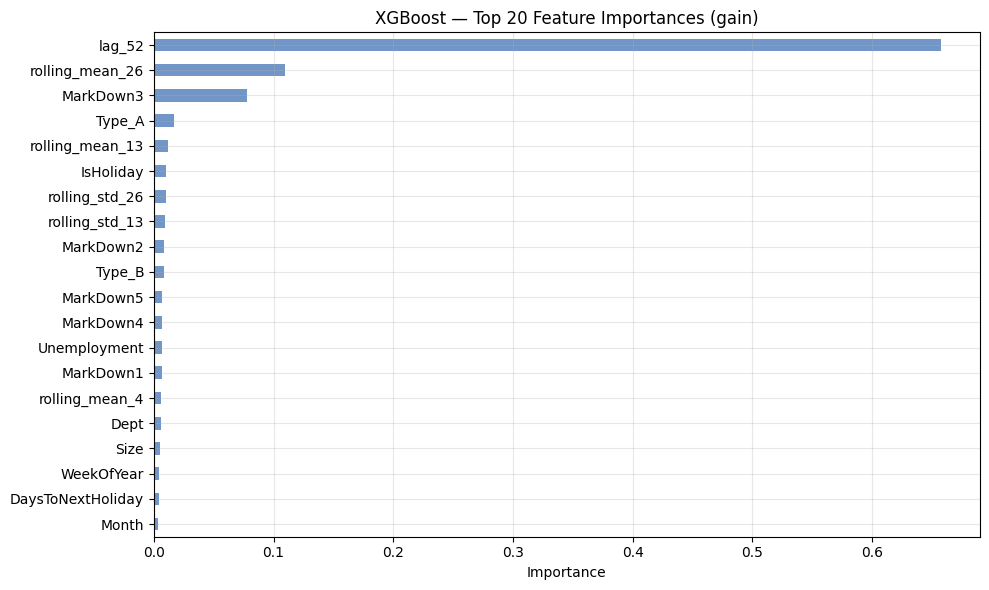

2026/07/16 14:17:35 INFO mlflow.tracking._tracking_service.client: 🏃 View run XGBoost_refine_4 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7/runs/87c73c7000ca4663b6c2da9b4532ee2b.
2026/07/16 14:17:35 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7.


lag_52               0.657204
rolling_mean_26      0.109871
MarkDown3            0.078192
Type_A               0.016629
rolling_mean_13      0.011603
IsHoliday            0.009992
rolling_std_26       0.009757
rolling_std_13       0.009446
MarkDown2            0.008699
Type_B               0.008341
MarkDown5            0.007219
MarkDown4            0.007153
Unemployment         0.006982
MarkDown1            0.006442
rolling_mean_4       0.005963
Dept                 0.005562
Size                 0.004808
WeekOfYear           0.004701
DaysToNextHoliday    0.004317
Month                0.003869
dtype: float32

In [17]:
importances = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns,
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
importances.sort_values().plot(kind="barh", ax=ax, color=BLUE)
ax.set_title("XGBoost — Top 20 Feature Importances (gain)")
ax.set_xlabel("Importance")
ax.grid(True, alpha=0.3)
plt.tight_layout()
fi_path = "Plots/xgboost_feature_importance.png"
plt.savefig(fi_path, dpi=200)
plt.show()

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(fi_path)
    for feat, imp in importances.items():
        mlflow.log_metric(f"fi_{feat}", float(imp))

display(importances)


### 18. Best Model — Final Training and Registration

In [18]:
print("Best label:",           best_label)
print("Best run id:",          best_run_id)
print("Best validation WMAE:", best_val_wmae)

assert best_label  is not None
assert best_run_id is not None

best_row = results_df[results_df["label"] == best_label].iloc[0]

_non_hyperparam_cols = {
    "label", "regime", "status", "feature_set",
    "train_wmae", "val_wmae", "gap_pct", "run_id",
}
_int_hyperparams = {"n_estimators", "max_depth", "min_child_weight"}
best_params = {}
for col in results_df.columns:
    if col in _non_hyperparam_cols:
        continue
    value = best_row[col]
    if pd.isna(value):
        continue
    best_params[col] = int(value) if col in _int_hyperparams else float(value)

print("Best params:"); display(best_params)

fallback_by_id = (
    train_feat.assign(
        unique_id=train_feat["Store"].astype(str) + "_" + train_feat["Dept"].astype(str)
    ).sort_values("Date").groupby("unique_id")["Weekly_Sales"].last().astype(float).to_dict()
)
global_fallback = float(train_feat["Weekly_Sales"].median())

# train_tail: last 52 rows per series (needed for lag computation at test time)
train_tail = (
    train_feat.sort_values(["Store", "Dept", "Date"])
    .groupby(["Store", "Dept"], group_keys=False)
    .tail(52)
    .reset_index(drop=True)
)

X_full, y_full, w_full, _ = build_xgb_matrices(train_feat, XGB_FEATURE_COLS)

with mlflow.start_run(run_name="XGBoost_FinalModel") as final_run:
    try:
        wandb_init_safe(
            entity=WANDB_ENTITY,
            project=WANDB_PROJECT,
            name="XGBoost_FinalModel",
            group="XGBoost",
            job_type="final_training",
            tags=["XGBoost", "final"],
            config={**CONFIG, **best_params, "best_val_wmae": best_val_wmae},
            reinit="finish_previous",
        )
        final_model = train_xgb(X_full, y_full, w_full, best_params)

        os.makedirs("artifacts", exist_ok=True)
        xgb_model_path = "artifacts/xgb_model.joblib"
        joblib.dump({
            "model":          final_model,
            "feature_cols":   XGB_FEATURE_COLS,
            "train_tail":     train_tail,
            "fallback_by_id": fallback_by_id,
            "global_fallback":global_fallback,
        }, xgb_model_path)

        pipeline = XGBForecastPipeline(
            feature_cols=XGB_FEATURE_COLS,
            fallback_by_id=fallback_by_id,
            global_fallback=global_fallback,
        )
        pipeline.model      = final_model
        pipeline.train_tail = train_tail

        test_enriched = apply_shared_features(test_df)
        sample_input  = test_enriched.head(5)
        sample_output = pipeline.predict(None, sample_input)
        signature     = infer_signature(sample_input, sample_output)

        mlflow.log_params({**best_params, "best_label": best_label,
                           "feature_set": XGB_FEATURE_DECISION["feature_set"]})
        mlflow.log_metric("best_val_wmae", best_val_wmae)
        mlflow.log_metric("n_train_rows",  len(X_full))

        model_uri = mlflow.pyfunc.log_model(
            artifact_path="xgb_model",
            python_model=pipeline,
            artifacts={"xgb_model_path": xgb_model_path},
            signature=signature,
            registered_model_name="XGBoost_WalmartForecast",
        ).model_uri

        wandb.log({"best_val_wmae": best_val_wmae, "n_train_rows": len(X_full)})
        print(f"Model registered. URI: {model_uri}")

    finally:
        wandb.finish()


Best label: refine_4
Best run id: 87c73c7000ca4663b6c2da9b4532ee2b
Best validation WMAE: 1692.1504895772182
Best params:


{'n_estimators': 2000,
 'max_depth': 9,
 'learning_rate': 0.005,
 'subsample': 0.9,
 'colsample_bytree': 0.9,
 'min_child_weight': 1,
 'reg_lambda': 0.2,
 'reg_alpha': 0.0,
 'gamma': 0.0}

/Users/macbookpro/Desktop/ml-final-project-walmart-recruiting/.venv311/lib/python3.11/site-packages/mlflow/types/utils.py:407: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/Users/macbookpro/Desktop/ml-final-project-walmart-recruiting/.venv311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets.

Model registered. URI: runs:/7a68ffc9a4e64f89bd82474c9df588be/xgb_model


Created version '2' of model 'XGBoost_WalmartForecast'.


best_val_wmae,▁
n_train_rows,▁
best_val_wmae,1692.15049
n_train_rows,261083


2026/07/16 14:23:44 INFO mlflow.tracking._tracking_service.client: 🏃 View run XGBoost_FinalModel at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7/runs/7a68ffc9a4e64f89bd82474c9df588be.
2026/07/16 14:23:44 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/7.


### 19. Test Loading

In [19]:
loaded_model = mlflow.pyfunc.load_model(model_uri)

test_enriched = apply_shared_features(test_df)
loaded_preds  = loaded_model.predict(test_enriched)

print(type(loaded_preds))
print(loaded_preds.shape)
display(loaded_preds.head())


<class 'pandas.core.frame.DataFrame'>
(115064, 2)


,Id,Weekly_Sales
0,1_1_2012-11-02,48300.339844
1,1_1_2012-11-09,20346.476562
2,1_1_2012-11-16,20762.201172
3,1_1_2012-11-23,22700.472656
4,1_1_2012-11-30,26408.195312
